# 04 — Modelo CNN com Imagens
### GalaxyNet — Classificador Morfológico de Galáxias

Rede Neural Convolucional (CNN) usando imagens de galáxias $(64 \times 64 \times 3)$ nas bandas $g$, $r$, $i$. Arquitetura: 4 blocos Conv2D(3x3) → BN → MaxPool → Dropout, seguidos de Dense(512) → Softmax(3).

Data augmentation com rotação 360°, flips e zoom para compensar o dataset pequeno (156 amostras).

In [1]:
import sys
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

def _find_src_dir():
    current = os.path.abspath(os.getcwd())
    for _ in range(5):
        candidate = os.path.join(current, 'src')
        if os.path.isdir(candidate):
            return candidate
        current = os.path.dirname(current)
    raise RuntimeError("Diretório src/ não encontrado.")

src_path = _find_src_dir()
if src_path not in sys.path:
    sys.path.insert(0, src_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.utils import to_categorical

from preprocessing import load_preprocessed_images, load_preprocessed_tabular
from models import create_cnn_model
from evaluation import evaluate_galaxy_classifier

# Reprodutibilidade
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Estilo dos gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# Caminhos
_project_root = os.path.dirname(src_path)
PROCESSED_DIR = os.path.join(_project_root, 'data', 'processed')
MODELS_DIR    = os.path.join(_project_root, 'models')
REPORTS_DIR   = os.path.join(_project_root, 'reports', 'figures')
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)

print(f"TensorFlow    : {tf.__version__}")
print(f"PROCESSED_DIR : {PROCESSED_DIR}")
print(f"MODELS_DIR    : {MODELS_DIR}")

I0000 00:00:1776218115.333554   11438 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776218115.369689   11438 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776218116.314127   11438 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow    : 2.21.0
PROCESSED_DIR : /home/luciano/Documentos/GalaxyNet/galaxy_classification/data/processed
MODELS_DIR    : /home/luciano/Documentos/GalaxyNet/galaxy_classification/models


---
## 1. Carregamento dos Dados

Carrega as imagens pré-processadas e os rótulos. As imagens e os dados tabulares são alinhados por `objid` para garantir correspondência correta entre imagens e labels.

In [2]:
# Carregar imagens pré-processadas
X_images, img_objids = load_preprocessed_images(PROCESSED_DIR)

# Carregar labels tabulares (mesma ordem de objids)
_, y_labels, tab_objids, _ = load_preprocessed_tabular(PROCESSED_DIR)

# Alinhar imagens e labels por objid
# Criar mapeamento objid → label
objid_to_label = dict(zip(tab_objids, y_labels))

# Filtrar apenas imagens que têm label correspondente e manter alinhamento
mask = np.array([oid in objid_to_label for oid in img_objids])
X_images = X_images[mask]
img_objids = img_objids[mask]
y_labels_aligned = np.array([objid_to_label[oid] for oid in img_objids])

print(f"\nX_images        : {X_images.shape}  dtype={X_images.dtype}")
print(f"y_labels        : {y_labels_aligned.shape}")
print(f"Valores em [0,1]: min={X_images.min():.4f}, max={X_images.max():.4f}")

print("\nDistribuição de classes:")
unique, counts = np.unique(y_labels_aligned, return_counts=True)
for cls, n in zip(unique, counts):
    print(f"  {cls:<12}: {n:>4} ({100*n/len(y_labels_aligned):.1f}%)")

Carregado de '/home/luciano/Documentos/GalaxyNet/galaxy_classification/data/processed':
  X_images   : (9054, 64, 64, 3)
  img_objids : 9054 IDs
Carregado de '/home/luciano/Documentos/GalaxyNet/galaxy_classification/data/processed':
  X_tabular : (9054, 15)
  y_labels  : 9054 rótulos
  objids    : 9054 IDs

X_images        : (9054, 64, 64, 3)  dtype=float32
y_labels        : (9054,)
Valores em [0,1]: min=0.0000, max=1.0000

Distribuição de classes:
  Elliptical  : 7595 (83.9%)
  Irregular   :  261 (2.9%)
  Spiral      : 1198 (13.2%)


---
## 2. Encoding de Labels e Split Train/Val/Test

Reutiliza o `LabelEncoder` salvo pelo notebook 03 para manter a mesma codificação entre modelos.

In [3]:
# Carregar LabelEncoder do notebook 03 para consistência
le_path = os.path.join(MODELS_DIR, 'label_encoder.pkl')
if os.path.exists(le_path):
    with open(le_path, 'rb') as f:
        label_encoder = pickle.load(f)
    print(f"LabelEncoder carregado de: {le_path}")
else:
    label_encoder = LabelEncoder()
    label_encoder.fit(y_labels_aligned)
    print("LabelEncoder ajustado localmente (label_encoder.pkl não encontrado)")

y_encoded = label_encoder.transform(y_labels_aligned)
y_one_hot = to_categorical(y_encoded)

num_classes = y_one_hot.shape[1]
print(f"Classes: {list(label_encoder.classes_)} → {list(range(num_classes))}")

# Split estratificado: 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp, objids_train, objids_temp = train_test_split(
    X_images, y_one_hot, img_objids,
    test_size=0.30, random_state=SEED, stratify=y_encoded
)

# Separar temp em val (50%) e test (50%)
# Stratify somente se todas as classes tiverem ≥2 amostras no temp
y_temp_encoded = np.argmax(y_temp, axis=1)
_, temp_counts = np.unique(y_temp_encoded, return_counts=True)
use_stratify = temp_counts.min() >= 2

X_val, X_test, y_val, y_test, objids_val, objids_test = train_test_split(
    X_temp, y_temp, objids_temp,
    test_size=0.50, random_state=SEED,
    stratify=y_temp_encoded if use_stratify else None
)

if not use_stratify:
    print("⚠ Classes minoritárias com <2 amostras no temp — segundo split sem stratify")

print(f"\nTrain : {X_train.shape[0]} amostras — shape {X_train.shape}")
print(f"Val   : {X_val.shape[0]} amostras")
print(f"Test  : {X_test.shape[0]} amostras")

for name, y_split in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    labels = label_encoder.inverse_transform(np.argmax(y_split, axis=1))
    unique, counts = np.unique(labels, return_counts=True)
    dist = ', '.join(f"{c}:{n}" for c, n in zip(unique, counts))
    print(f"  {name}: {dist}")

LabelEncoder carregado de: /home/luciano/Documentos/GalaxyNet/galaxy_classification/models/label_encoder.pkl
Classes: ['Elliptical', 'Irregular', 'Spiral'] → [0, 1, 2]

Train : 6337 amostras — shape (6337, 64, 64, 3)
Val   : 1358 amostras
Test  : 1359 amostras
  Train: Elliptical:5316, Irregular:183, Spiral:838
  Val: Elliptical:1139, Irregular:39, Spiral:180
  Test: Elliptical:1140, Irregular:39, Spiral:180


---
## 3. Data Augmentation e Class Weights

Galáxias não possuem orientação preferencial no céu, o que justifica:
- **Rotação 360°**: qualquer ângulo é fisicamente válido
- **Flips horizontal e vertical**: simetria do céu
- **Zoom 0.8–1.2**: simula diferentes distâncias angulares
- **Brightness 0.8–1.2**: simula variações de exposição

O `fill_mode='constant'` com `cval=0.0` preenche bordas com zero (céu escuro).

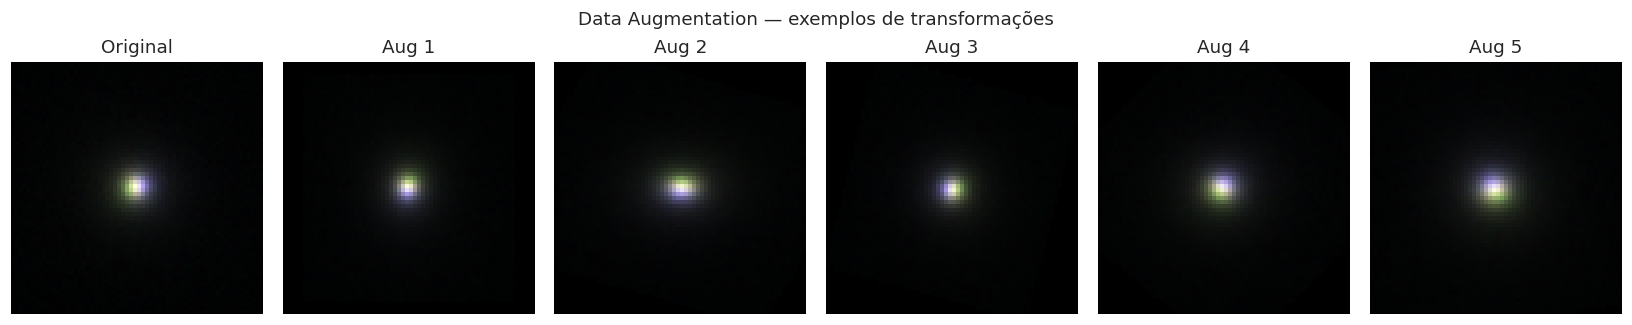

Figura salva: fig18_cnn_data_augmentation.png

Class weights (balanced) — antes do SMOTE:
  Elliptical   (idx=0): weight=0.397  (n_train=5316)
  Irregular    (idx=1): weight=11.543  (n_train=183)
  Spiral       (idx=2): weight=2.521  (n_train=838)


In [4]:
# Data augmentation — apenas no treino
# (sem brightness_range: imagens ja estao min-max normalizadas em [0,1],
# e brightness shift desestabiliza as estatisticas do BatchNorm)
datagen = ImageDataGenerator(
    rotation_range=360,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    fill_mode='constant',
    cval=0.0,
)

# Visualizar exemplos de data augmentation
sample_img = X_train[0:1]
fig, axes = plt.subplots(1, 6, figsize=(15, 3))
axes[0].imshow(np.stack([sample_img[0,:,:,1], sample_img[0,:,:,0], sample_img[0,:,:,2]], axis=-1),
               origin='lower')
axes[0].set_title('Original')
axes[0].axis('off')

for i, batch in enumerate(datagen.flow(sample_img, batch_size=1)):
    if i >= 5:
        break
    img = batch[0]
    rgb = np.stack([img[:,:,1], img[:,:,0], img[:,:,2]], axis=-1)
    axes[i+1].imshow(np.clip(rgb, 0, 1), origin='lower')
    axes[i+1].set_title(f'Aug {i+1}')
    axes[i+1].axis('off')

fig.suptitle('Data Augmentation — exemplos de transformações', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'fig18_cnn_data_augmentation.png'), bbox_inches='tight')
plt.show()
print('Figura salva: fig18_cnn_data_augmentation.png')

# Class weights (ainda calculados para fins de log — serao desativados pela
# celula SMOTE que vem a seguir, ja que o treino ficara balanceado.)
y_train_integers = np.argmax(y_train, axis=1)
class_weights_array = compute_class_weight(
    'balanced',
    classes=np.unique(y_train_integers),
    y=y_train_integers,
)
class_weight_dict = dict(enumerate(class_weights_array))

print("\nClass weights (balanced) — antes do SMOTE:")
for idx, weight in class_weight_dict.items():
    cls_name = label_encoder.inverse_transform([idx])[0]
    n_train = (y_train_integers == idx).sum()
    print(f"  {cls_name:<12} (idx={idx}): weight={weight:.3f}  (n_train={n_train})")


In [5]:
# ───────────────────────────────────────────────────────────────────────────
# SMOTE oversampling — balanceia as classes APENAS no conjunto de TREINO.
# SMOTE opera em vetores 2D, então achatamos (N, 64, 64, 3) -> (N, 12288),
# aplicamos o oversampling e reformatamos de volta. Val/test permanecem intactos.
# k_neighbors é limitado pela classe minoritária (Irregular ~186 no train).
# ───────────────────────────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE
from collections import Counter

n_train_before = X_train.shape[0]
img_shape = X_train.shape[1:]                        # (64, 64, 3)

X_train_flat = X_train.reshape(n_train_before, -1)   # (N, 12288)
y_train_int  = np.argmax(y_train, axis=1)

counts_before = Counter(y_train_int)
n_min = min(counts_before.values())
k_nn  = max(1, min(5, n_min - 1))
print(f"Distribuicao antes do SMOTE: {dict(counts_before)}  (k_neighbors={k_nn})")

smote = SMOTE(random_state=SEED, k_neighbors=k_nn)
X_train_flat_res, y_train_int_res = smote.fit_resample(X_train_flat, y_train_int)

# SMOTE pode gerar valores levemente fora de [0,1] por interpolacao; recortamos.
X_train = np.clip(X_train_flat_res, 0.0, 1.0).reshape(-1, *img_shape).astype(np.float32)
y_train = to_categorical(y_train_int_res, num_classes=num_classes)

counts_after = Counter(y_train_int_res)
print(f"Distribuicao depois do SMOTE: {dict(counts_after)}")
print(f"Train pos-SMOTE: {X_train.shape[0]} amostras (antes: {n_train_before})")

# Com SMOTE balanceando o treino, desativamos class_weight para nao duplicar
# a compensacao de desbalanceamento.
class_weight_dict = None
print("class_weight desativado (SMOTE ja balanceia o treino).")


Distribuicao antes do SMOTE: {np.int64(0): 5419, np.int64(2): 862, np.int64(1): 186}  (k_neighbors=5)
Distribuicao depois do SMOTE: {np.int64(0): 5419, np.int64(2): 5419, np.int64(1): 5419}
Train pos-SMOTE: 16257 amostras (antes: 6467)
class_weight desativado (SMOTE ja balanceia o treino).


---
## 4. Criação do Modelo CNN

In [5]:
input_shape = X_train.shape[1:]  # (64, 64, 3)
cnn_model = create_cnn_model(input_shape, num_classes)
cnn_model.summary()

E0000 00:00:1776218137.403480   11438 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1776218137.403983   11576 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1776218137.426257   11438 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,491,587 (9.50 MB)

 Trainable params: 2,489,603 (9.50 MB)

 Non-trainable params: 1,984 (7.75 KB)

---
## 5. Treinamento

O treinamento usa `datagen.flow()` para aplicar data augmentation em tempo real a cada batch. A validação usa os dados originais (sem augmentation).

- **EarlyStopping**: patience=15, restaura melhores pesos
- **ReduceLROnPlateau**: reduz LR pela metade se val_loss estagnar por 7 épocas

In [6]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=7, min_lr=1e-7, verbose=1
    ),
]

history = cnn_model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val),
    epochs=100,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1,
)

print(f"\nTreinamento finalizado em {len(history.history['loss'])} épocas.")

Epoch 1/100


I0000 00:00:1776218141.724608   11438 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


199/199 ━━━━━━━━━━━━━━━━━━━━ 28s 128ms/step - accuracy: 0.5422 - loss: 1.4723 - val_accuracy: 0.6878 - val_loss: 1.1750 - learning_rate: 0.0010
Epoch 2/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 25s 124ms/step - accuracy: 0.5955 - loss: 1.2291 - val_accuracy: 0.6215 - val_loss: 0.9472 - learning_rate: 0.0010
Epoch 3/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 25s 128ms/step - accuracy: 0.6448 - loss: 1.0758 - val_accuracy: 0.8063 - val_loss: 0.6952 - learning_rate: 0.0010
Epoch 4/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 25s 124ms/step - accuracy: 0.6732 - loss: 0.9987 - val_accuracy: 0.8284 - val_loss: 1.4526 - learning_rate: 0.0010
Epoch 5/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 26s 129ms/step - accuracy: 0.6898 - loss: 0.9638 - val_accuracy: 0.8579 - val_loss: 0.5303 - learning_rate: 0.0010
Epoch 6/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 26s 133ms/step - accuracy: 0.7182 - loss: 0.9089 - val_accuracy: 0.8468 - val_loss: 0.7379 - learning_rate: 0.0010
Epoch 7/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 26s 131ms/step - accuracy: 0.7125 -

199/199 ━━━━━━━━━━━━━━━━━━━━ 25s 126ms/step - accuracy: 0.8619 - loss: 0.5448 - val_accuracy: 0.8822 - val_loss: 0.4754 - learning_rate: 1.2500e-04
Epoch 40: early stopping
Restoring model weights from the end of the best epoch: 25.

Treinamento finalizado em 40 épocas.


---
## 6. Curvas de Treinamento (Loss e Accuracy)

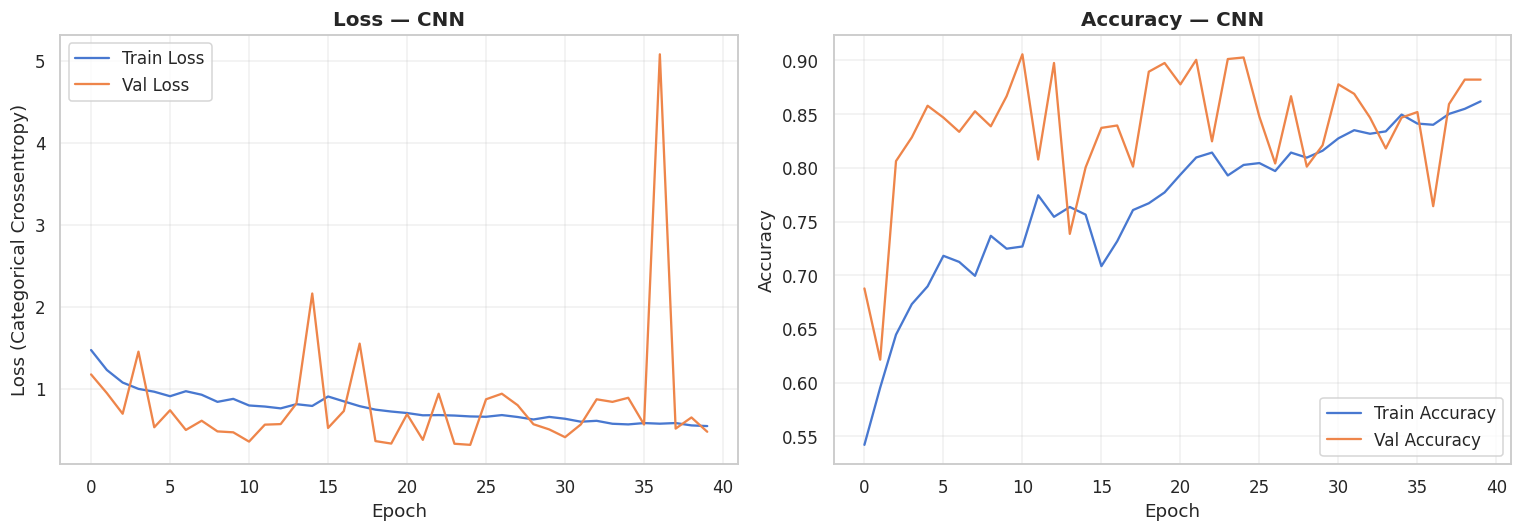

Figura salva: fig19_cnn_training_curves.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss — CNN', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (Categorical Crossentropy)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy — CNN', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'fig19_cnn_training_curves.png'),
            bbox_inches='tight')
plt.show()
print('Figura salva: fig19_cnn_training_curves.png')

---
## 7. Avaliação no Conjunto de Teste

CNN Test Loss: 0.2876, Test Accuracy: 0.9007

--- Evaluation for CNN Model ---

Classification Report:
              precision    recall  f1-score   support

  Elliptical       0.95      0.96      0.95      1140
   Irregular       0.23      0.21      0.22        39
      Spiral       0.71      0.67      0.69       180

    accuracy                           0.90      1359
   macro avg       0.63      0.61      0.62      1359
weighted avg       0.90      0.90      0.90      1359


Confusion matrix salva em: /home/luciano/Documentos/GalaxyNet/galaxy_classification/reports/figures/fig17_cnn_confusion_matrix.png


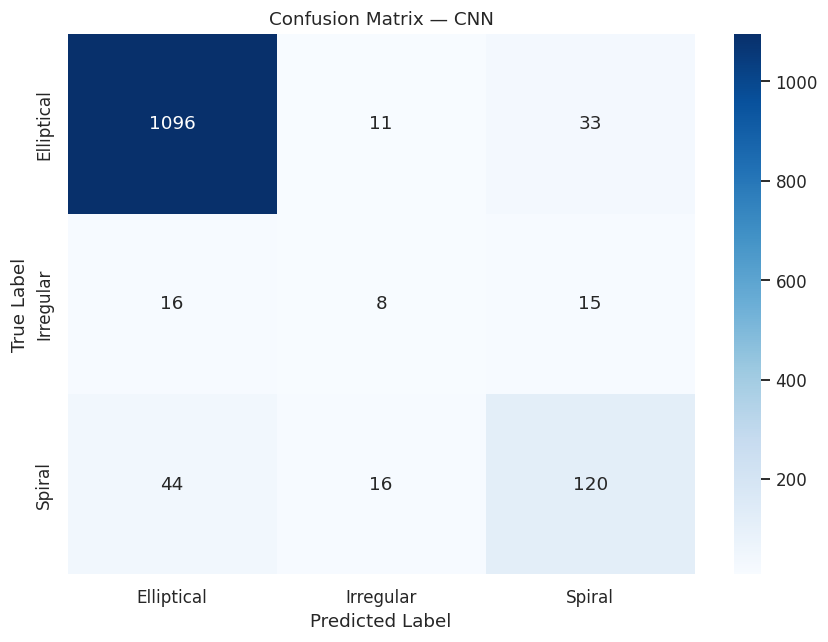


Scientific Metrics (Completeness and Reliability per Class):
     Class  N_True Completeness (Recall) Reliability (Precision)
Elliptical    1140                 0.961                   0.948
 Irregular      39                 0.205                   0.229
    Spiral     180                 0.667                   0.714


In [8]:
loss, accuracy = cnn_model.evaluate(X_test, y_test, verbose=0)
print(f"CNN Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

eval_results = evaluate_galaxy_classifier(
    model=cnn_model,
    X_test_data=X_test,
    y_test_one_hot=y_test,
    label_encoder=label_encoder,
    model_type='CNN',
    save_dir=REPORTS_DIR,
)

---
## 8. Salvar Modelo

In [9]:
# Salvar modelo treinado
model_path = os.path.join(MODELS_DIR, 'cnn_galaxy_classifier.h5')
cnn_model.save(model_path)
print(f"Modelo salvo em: {model_path}")

# Salvar dados de teste para comparação posterior entre modelos
test_artifacts = {
    'X_test': X_test,
    'y_test': y_test,
    'objids_test': objids_test,
}
test_path = os.path.join(MODELS_DIR, 'cnn_test_data.pkl')
with open(test_path, 'wb') as f:
    pickle.dump(test_artifacts, f)
print(f"Dados de teste salvos em: {test_path}")

Modelo salvo em: /home/luciano/Documentos/GalaxyNet/galaxy_classification/models/cnn_galaxy_classifier.h5
Dados de teste salvos em: /home/luciano/Documentos/GalaxyNet/galaxy_classification/models/cnn_test_data.pkl


---
## 9. Resumo

In [10]:
print("=" * 55)
print("RESUMO — MODELO CNN COM IMAGENS")
print("=" * 55)
print(f"Input shape          : {input_shape}")
print(f"Classes              : {list(label_encoder.classes_)}")
print(f"Amostras (train/val/test): {X_train.shape[0]}/{X_val.shape[0]}/{X_test.shape[0]}")
print(f"Data augmentation    : rotation=360°, flips, zoom=0.2, brightness=[0.8,1.2]")
print(f"Épocas treinadas     : {len(history.history['loss'])}")
print(f"Test Loss            : {loss:.4f}")
print(f"Test Accuracy        : {accuracy:.4f}")
print()
print("Métricas Científicas:")
print(eval_results['scientific_metrics'].to_string(index=False))
print()
print("Artefatos salvos:")
print(f"  1. {model_path}")
print(f"  2. reports/figures/fig18_cnn_data_augmentation.png")
print(f"  3. reports/figures/fig19_cnn_training_curves.png")
print(f"  4. reports/figures/fig17_cnn_confusion_matrix.png")

RESUMO — MODELO CNN COM IMAGENS
Input shape          : (64, 64, 3)
Classes              : ['Elliptical', 'Irregular', 'Spiral']
Amostras (train/val/test): 6337/1358/1359
Data augmentation    : rotation=360°, flips, zoom=0.2, brightness=[0.8,1.2]
Épocas treinadas     : 40
Test Loss            : 0.2876
Test Accuracy        : 0.9007

Métricas Científicas:
     Class  N_True Completeness (Recall) Reliability (Precision)
Elliptical    1140                 0.961                   0.948
 Irregular      39                 0.205                   0.229
    Spiral     180                 0.667                   0.714

Artefatos salvos:
  1. /home/luciano/Documentos/GalaxyNet/galaxy_classification/models/cnn_galaxy_classifier.h5
  2. reports/figures/fig18_cnn_data_augmentation.png
  3. reports/figures/fig19_cnn_training_curves.png
  4. reports/figures/fig17_cnn_confusion_matrix.png
